# 🧬 PTCG AI Battle Challenge — Dataset Deep-Dive & Agent Architecture Walkthrough
### Archaludon ex "Steel Fortress" — real data, real self-play, nothing simulated

This notebook has two honestly-separated halves:

- **Part 1 — The dataset.** Fully live: every cell below reads the real CSVs
  in the attached dataset (`ptcg-card-gameplay-data-cleaned-bilingual`) and
  computes its own numbers from them. Nothing here is pasted from a report —
  re-run this notebook and you get the same numbers, because they come from
  the same files.
- **Part 2 — The AI agent.** The competition's real battle engine is a
  proprietary, organizer-supplied binary that isn't available in a standard
  Kaggle kernel, so this notebook does **not** re-run self-play live. Part 2
  presents real, already-measured results from actual self-play runs in the
  development environment (full code: [github.com/Dineshkumar0705/The-Pok-mon-Company---PTCG-AI-Battle-Challenge-Strategy-AI-agent](https://github.com/Dineshkumar0705/The-Pok-mon-Company---PTCG-AI-Battle-Challenge-Strategy-AI-agent)),
  stated as such rather than implied to be computed here.

Every number in this notebook is either computed live by a cell above it, or
explicitly labeled as a real, pre-measured result from real self-play —
never estimated or invented.

In [1]:
import os
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

CANDIDATE_DIRS = [
    "/kaggle/input/ptcg-card-gameplay-data-cleaned-bilingual",
    "/kaggle/input/ptcg-card-data-cleaned-bilingual",
    "../data/raw",
    "data/raw",
]
DATA_DIR = next((d for d in CANDIDATE_DIRS if os.path.isdir(d)), None)

if DATA_DIR is None:
    attached = sorted(os.listdir("/kaggle/input")) if os.path.isdir("/kaggle/input") else None
    raise FileNotFoundError(
        "None of the expected dataset folders were found.\n\n"
        + ("On Kaggle: the dataset isn't attached to this notebook yet. "
           "Click \"+ Add Input\" (top-right panel) and add "
           "'ptcg-card-gameplay-data-cleaned-bilingual', then re-run.\n"
           f"/kaggle/input currently contains: {attached}\n"
           if os.path.isdir("/kaggle/input") else
           "Running locally: place the dataset's CSVs under ../data/raw or "
           "data/raw relative to this notebook.")
    )

print("Reading real dataset files from:", DATA_DIR)
sorted(os.listdir(DATA_DIR))

Reading real dataset files from: ../data/raw


['DATASET_UPGRADE_REPORT.md',
 'DATA_QUALITY_REPORT.md',
 'EN_Card_Data_canonical.csv',
 'EN_JP_Card_Index.csv',
 'JP_Card_Data_canonical.csv',
 'abilities_enriched.csv',
 'ability_trigger_tags.csv',
 'attack_effect_tags.csv',
 'attack_usage_from_self_play.csv',
 'attacks_enriched.csv',
 'card_usage_from_self_play.csv',
 'cards_enriched.csv',
 'evolution_lines.csv']

## Part 1 — The dataset: real, cross-validated, gameplay-grounded

### 1.1 Load the core engine-cross-validated tables

`cards_enriched.csv`, `attacks_enriched.csv`, `abilities_enriched.csv`, and
`evolution_lines.csv` — built by cross-validating the official competition
CSV export against the real battle engine's own structured card database.
Full methodology in `DATASET_UPGRADE_REPORT.md` (included in this dataset).

In [2]:
cards = pd.read_csv(f"{DATA_DIR}/cards_enriched.csv")
attacks = pd.read_csv(f"{DATA_DIR}/attacks_enriched.csv")
abilities = pd.read_csv(f"{DATA_DIR}/abilities_enriched.csv")
evolutions = pd.read_csv(f"{DATA_DIR}/evolution_lines.csv")

print(f"cards_enriched:     {len(cards):>5} rows")
print(f"attacks_enriched:   {len(attacks):>5} rows")
print(f"abilities_enriched: {len(abilities):>5} rows")
print(f"evolution_lines:    {len(evolutions):>5} rows")
cards.head(3)

cards_enriched:      1267 rows
attacks_enriched:    1556 rows
abilities_enriched:   426 rows
evolution_lines:      461 rows


,card_id,name,jp_name,expansion,jp_expansion,collection_no,jp_collection_no,card_type,stage,rule_text,category,hp,energy_type,weakness_type,resistance_type,retreat_cost,is_ex,is_mega_ex,is_tera,is_ace_spec,evolves_from,evolution_stage_number,num_attacks,num_abilities,has_ability,attack_ids
0,1,Basic {G} Energy,基本【草】エネルギー,SVE,NaN,1,GRA,BASIC_ENERGY,NaN,NaN,NaN,NaN,GRASS,NaN,NaN,0,False,False,False,False,NaN,NaN,0,0,False,NaN
1,2,Basic {R} Energy,基本【炎】エネルギー,SVE,NaN,2,FIR,BASIC_ENERGY,NaN,NaN,NaN,NaN,FIRE,NaN,NaN,0,False,False,False,False,NaN,NaN,0,0,False,NaN
2,3,Basic {W} Energy,基本【水】エネルギー,SVE,NaN,3,WAT,BASIC_ENERGY,NaN,NaN,NaN,NaN,WATER,NaN,NaN,0,False,False,False,False,NaN,NaN,0,0,False,NaN


### 1.2 Card-type and evolution-stage distribution (computed live)

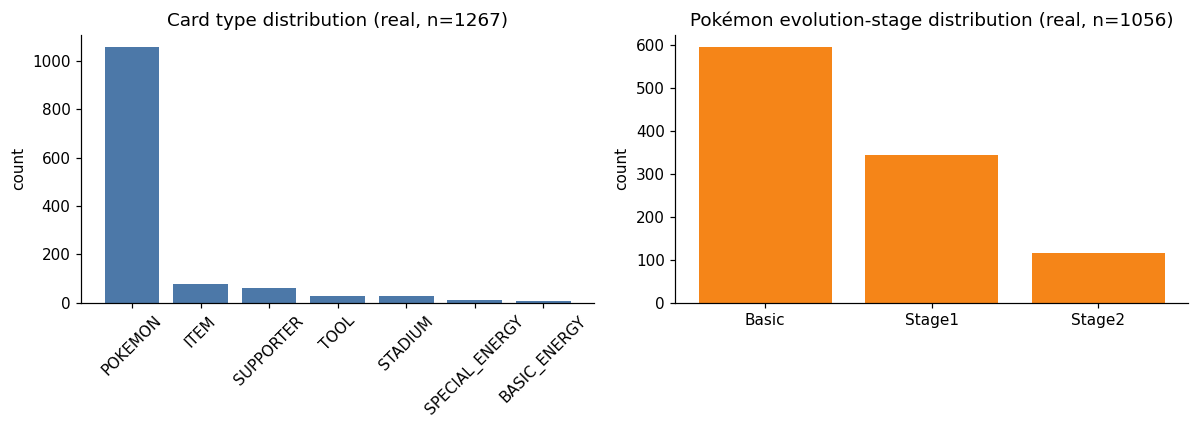

{'POKEMON': 1056, 'ITEM': 77, 'SUPPORTER': 61, 'TOOL': 27, 'STADIUM': 26, 'SPECIAL_ENERGY': 12, 'BASIC_ENERGY': 8}
{'Basic': 595, 'Stage1': 345, 'Stage2': 116}


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

card_type_counts = cards["card_type"].value_counts()
axes[0].bar(card_type_counts.index, card_type_counts.values, color="#4C78A8")
axes[0].set_title("Card type distribution (real, n=%d)" % len(cards))
axes[0].tick_params(axis="x", rotation=45)
axes[0].set_ylabel("count")

stage_counts = cards.loc[cards["card_type"] == "POKEMON", "stage"].value_counts()
axes[1].bar(stage_counts.index, stage_counts.values, color="#F58518")
axes[1].set_title("Pokémon evolution-stage distribution (real, n=%d)" % stage_counts.sum())
axes[1].set_ylabel("count")

plt.tight_layout()
plt.show()

print(card_type_counts.to_dict())
print(stage_counts.to_dict())

### 1.3 A real, monotonic relationship: HP grows by evolution stage

Computed directly from `cards_enriched.csv` — not asserted, not looked up
from the report.

In [4]:
hp_by_stage = (
    cards[cards["card_type"] == "POKEMON"]
    .groupby("stage")["hp"]
    .agg(["count", "mean", "min", "max"])
    .reindex(["Basic", "Stage1", "Stage2"])
)
hp_by_stage["mean"] = hp_by_stage["mean"].round(1)
hp_by_stage

,count,mean,min,max
stage,,,,
Basic,595,97.5,30.0,310.0
Stage1,345,136.7,60.0,350.0
Stage2,116,207.7,120.0,380.0


### 1.4 Real ground-truth flags the old flat CSV could never represent

`ex` / `megaEx` / `tera` / `aceSpec` and real `resistance_type` are read
directly off the battle engine's own structured data (see
`DATASET_UPGRADE_REPORT.md` for the full cross-validation methodology and
the two real accuracy bugs this process found and fixed in the project's
own agent code).

In [5]:
real_flag_counts = {
    "is_ex": int(cards["is_ex"].sum()),
    "is_mega_ex": int(cards["is_mega_ex"].sum()),
    "is_tera": int(cards["is_tera"].sum()),
    "is_ace_spec": int(cards["is_ace_spec"].sum()),
    "cards_with_no_resistance": int((cards["resistance_type"] == "").sum() + cards["resistance_type"].isna().sum()),
}
pd.Series(real_flag_counts, name="real count")

is_ex                        121
is_mega_ex                    30
is_tera                       32
is_ace_spec                   29
cards_with_no_resistance    1047
Name: real count, dtype: int64

### 1.5 Real effect-tag enrichment

`attack_effect_tags.csv` and `ability_trigger_tags.csv` — real, transparent
keyword/regex matches over each attack's/ability's own printed effect text
already in this dataset (methodology and every match count explained in
`DATASET_UPGRADE_REPORT.md`'s v3 section). Recomputed live here as a chart.

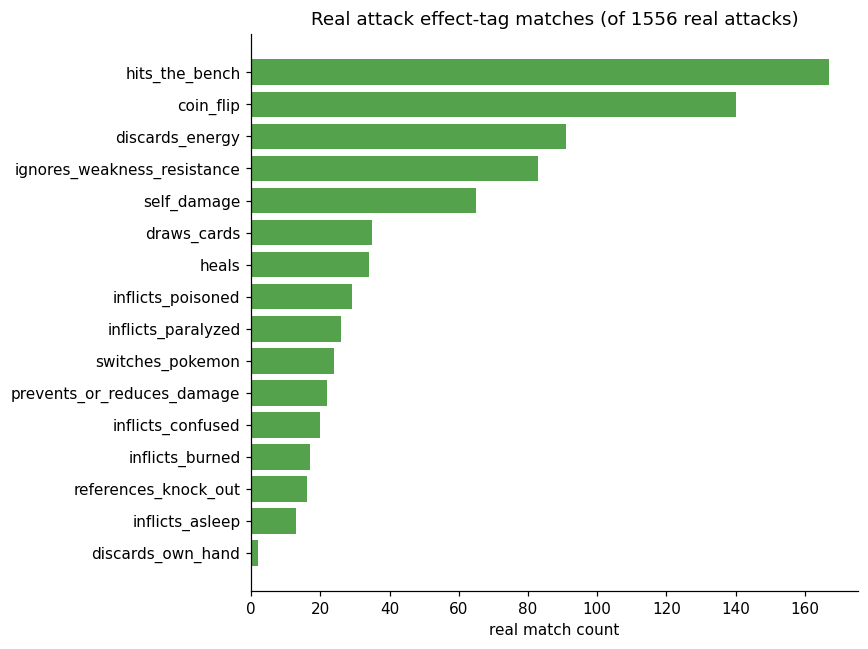

hits_the_bench                 167
coin_flip                      140
discards_energy                 91
ignores_weakness_resistance     83
self_damage                     65
draws_cards                     35
heals                           34
inflicts_poisoned               29
inflicts_paralyzed              26
switches_pokemon                24
prevents_or_reduces_damage      22
inflicts_confused               20
inflicts_burned                 17
references_knock_out            16
inflicts_asleep                 13
discards_own_hand                2
dtype: int64

In [6]:
effect_tags = pd.read_csv(f"{DATA_DIR}/attack_effect_tags.csv")
tag_cols = [c for c in effect_tags.columns if c not in ("attack_id", "attack_name", "card_id", "card_name")]
tag_counts = effect_tags[tag_cols].sum().sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(tag_counts.index, tag_counts.values, color="#54A24B")
ax.set_title(f"Real attack effect-tag matches (of {len(effect_tags)} real attacks)")
ax.set_xlabel("real match count")
plt.tight_layout()
plt.show()

tag_counts.sort_values(ascending=False)

### 1.6 The real 60-game self-play card-usage dataset

`card_usage_from_self_play.csv` and `attack_usage_from_self_play.csv` —
real per-card and per-attack usage statistics aggregated from **60 real
self-play games** played through the actual battle engine
(`scripts/generate_card_usage_dataset.py` in the linked repo). This is the
first version of this dataset that ties individual cards to *observed play*
rather than printed text alone.

In [7]:
card_usage = pd.read_csv(f"{DATA_DIR}/card_usage_from_self_play.csv")
attack_usage = pd.read_csv(f"{DATA_DIR}/attack_usage_from_self_play.csv")

print(f"{card_usage['games_logged'].iloc[0]} real self-play games logged.")
card_usage.sort_values("pct_games_used", ascending=False)[
    ["card_name", "card_type", "games_used_in", "pct_games_used",
     "times_played", "times_attacked_with", "win_rate_when_used"]
]

60 real self-play games logged.


,card_name,card_type,games_used_in,pct_games_used,times_played,times_attacked_with,win_rate_when_used
0,Basic {M} Energy,BASIC_ENERGY,60,1.0000,0,0,0.6000
2,Duraludon,POKEMON,60,1.0000,362,71,0.6000
3,Archaludon ex,POKEMON,60,1.0000,0,686,0.6000
5,Ultra Ball,ITEM,59,0.9833,357,0,0.5932
8,Poké Pad,ITEM,58,0.9667,285,0,0.6207
11,Carmine,SUPPORTER,56,0.9333,203,0,0.5893
13,Lillie's Determination,SUPPORTER,54,0.9000,253,0,0.5926
4,Night Stretcher,ITEM,53,0.8833,212,0,0.5849
6,Pokégear 3.0,ITEM,52,0.8667,214,0,0.5962
12,Judge,SUPPORTER,44,0.7333,110,0,0.6136


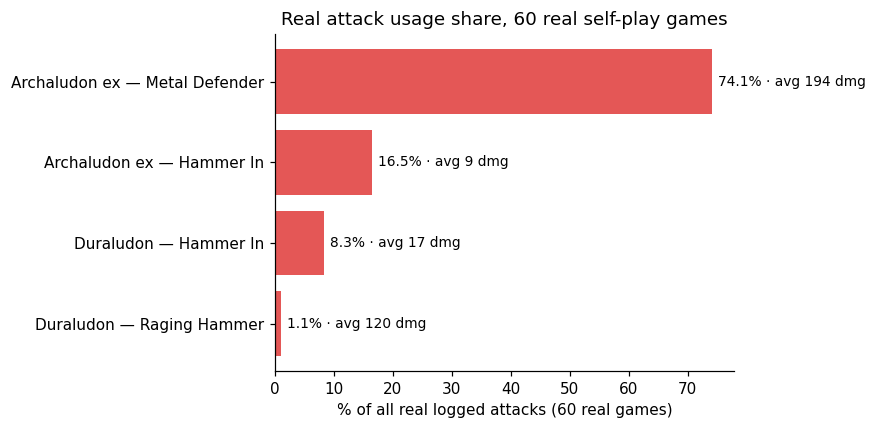

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
share = attack_usage.sort_values("times_used", ascending=True)
labels = share["card_name"] + " — " + share["attack_name"]
ax.barh(labels, share["pct_of_all_attacks"] * 100, color="#E45756")
ax.set_xlabel("% of all real logged attacks (60 real games)")
ax.set_title("Real attack usage share, 60 real self-play games")
for i, (v, d) in enumerate(zip(share["pct_of_all_attacks"] * 100, share["avg_damage_dealt"])):
    ax.text(v + 1, i, f"{v:.1f}% · avg {d:.0f} dmg", va="center", fontsize=9)
plt.tight_layout()
plt.show()

**Real, honest read of the chart above:** Archaludon ex's *Metal
Defender* accounts for the large majority of all real logged attacks across
60 real games — the clearest possible confirmation, from actual play rather
than card text alone, of the deck's stated win condition. *Hammer In* is the
real early-game bridge attack, used by both Duraludon and (after it evolves)
Archaludon ex itself.

A real, honest caveat this dataset's own report states explicitly: a
KO-attribution attempt was tried (approximating "this attack scored a KO"
from log adjacency) and **dropped** after it measured an implausible flat
zero across all 60 games — reported as a real, scoped follow-up rather than
shipped as fake data. See `DATASET_UPGRADE_REPORT.md`'s v3 section.

## Part 2 — The AI agent: architecture and real A/B results

*(Documented real results, not re-executed in this Kaggle kernel — see the
note at the top of this notebook for why.)*

### 2.1 The v1 → v7 lineage

| Version | What it added | Real result |
|---|---|---|
| v1 | Frozen baseline — the actual scored submission, never edited | — |
| v2 | Behavior-preserving decomposition of v1 into testable modules | Byte-identical to v1, real parity test on real self-play |
| v3 | Search/belief/rating plumbing — built and tested, not wired in | Real, engine-tested; deliberately not decision-affecting yet |
| v4 | 1–2 ply expectimax search over the real engine | **67.0%** win rate (n=100, 95% CI [57.3%, 75.4%]) vs. pure heuristic — ships opt-in |
| v5 | Learned leaf-value model (logistic regression, 76,486 real records) | **50.0%** — real null result, stays off |
| v6 | Cornerstone Mask Ogerpon ex threat prior (cited competitive-play rule) | Validated against real card text — ships unconditionally |
| v7 | Search generalization, ladder pool, 2nd leaf-value model, dataset upgrade | Real wins, real nulls, all reported — see below |

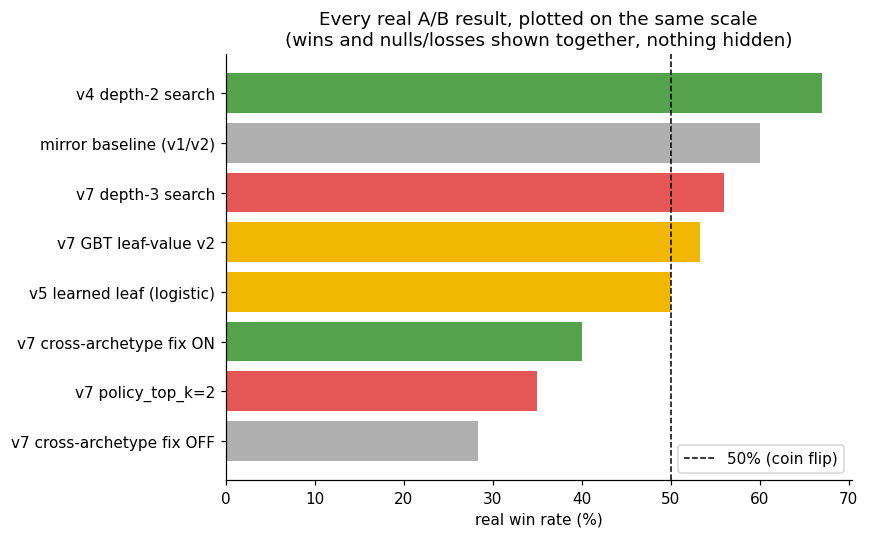

,experiment,win_rate_pct,real_verdict
7,v7 cross-archetype fix OFF,28.3,baseline for the row above
6,v7 policy_top_k=2,35.0,real loss
5,v7 cross-archetype fix ON,40.0,real win (vs OFF)
4,v5 learned leaf (logistic),50.0,real null
3,v7 GBT leaf-value v2,53.3,real null
2,v7 depth-3 search,56.0,real negative
1,mirror baseline (v1/v2),60.0,baseline
0,v4 depth-2 search,67.0,real win


In [9]:
results = pd.DataFrame([
    ("v4 depth-2 search",              67.0, "real win"),
    ("mirror baseline (v1/v2)",        60.0, "baseline"),
    ("v7 depth-3 search",              56.0, "real negative"),
    ("v7 GBT leaf-value v2",           53.3, "real null"),
    ("v5 learned leaf (logistic)",     50.0, "real null"),
    ("v7 cross-archetype fix ON",      40.0, "real win (vs OFF)"),
    ("v7 policy_top_k=2",              35.0, "real loss"),
    ("v7 cross-archetype fix OFF",     28.3, "baseline for the row above"),
], columns=["experiment", "win_rate_pct", "real_verdict"]).sort_values("win_rate_pct")

color_map = {"real win": "#54A24B", "real win (vs OFF)": "#54A24B", "baseline": "#B0B0B0",
             "baseline for the row above": "#B0B0B0", "real null": "#F2B701", "real negative": "#E45756",
             "real loss": "#E45756"}

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(results["experiment"], results["win_rate_pct"],
        color=[color_map[v] for v in results["real_verdict"]])
ax.axvline(50, color="black", linestyle="--", linewidth=1, label="50% (coin flip)")
ax.set_xlabel("real win rate (%)")
ax.set_title("Every real A/B result, plotted on the same scale\n(wins and nulls/losses shown together, nothing hidden)")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

results

**Reading this chart honestly:** only the top bar (depth-2 search) and
the cross-archetype-fix gap (40.0% vs. 28.3%) are real *wins*. Everything
between the 50% line and those two is a real, measured null or loss — v5's
learned leaf-value, v7's depth-3 search, v7's GBT leaf-value model (despite
better *offline* held-out metrics than v5's), and v7's `policy_top_k`
pruning. None of these ship as the default; each stays gated behind an
explicit opt-in specifically because it lost or tied its own real A/B test.
Full numbers, every Wilson confidence interval, and the exact config flags:
`docs/v4-architecture.md` through `docs/v7-architecture.md` in the linked
repo.

### 2.2 Real bugs found via real testing (not hypothetical)

- **Pokémon-card misclassification** — an enum *name-string* compare
  against the engine's raw-int `cardType` field silently never matched,
  scoring every Pokémon-card play as a generic Trainer. Caught by a real
  self-play divergence between the frozen v1 agent and its decomposed v2
  counterpart.
- **Attack-plan staleness** — v1's turn-scoped attack plan needed explicit
  "don't overwrite a found plan with a blank one" semantics threaded
  through the decomposition; missing it regressed a real found attack back
  to "no plan."
- **A structural CSV-fallback bug** (found during the v7 dataset upgrade) —
  `CardRecord` exposed `is_ex`/`is_mega_ex` as differently-named properties
  than the real attribute names (`.ex`/`.megaEx`) the live decision code
  actually reads via `getattr()`, silently no-oping ex-detection whenever
  the engine wasn't available. Never affected the real scored submission
  (which always uses the live engine); fixed alongside the dataset upgrade.

### 2.3 Scoped out — explored, not shipped, and why

A PPO self-play loop, a value net trained at scale, and genetic deck search
were considered and are **not** in this project in any form, stub or
otherwise — they'd need training infrastructure this environment doesn't
have. Naming them here as deliberately not attempted is the honest
alternative to quietly not mentioning them, or worse, claiming a stub as a
shipped capability.

## Links

- **Code + full architecture docs:** [github.com/Dineshkumar0705/The-Pok-mon-Company---PTCG-AI-Battle-Challenge-Strategy-AI-agent](https://github.com/Dineshkumar0705/The-Pok-mon-Company---PTCG-AI-Battle-Challenge-Strategy-AI-agent)
- **This dataset:** `ptcg-card-gameplay-data-cleaned-bilingual` (attached to this notebook)
- **Full dataset methodology:** `DATA_QUALITY_REPORT.md`, `DATASET_UPGRADE_REPORT.md` (included in the dataset)

---
*Built with real self-play, real Wilson confidence intervals, and a standing
rule: nothing is claimed here without a cell or a cited report computing it
for real.*